<table style="border-collapse: collapse; border: none;">
  <tr>
    <td style="vertical-align: top; border: none;">
      <img src="https://i.imgur.com/x6poGzn.png" width="130" height="170" alt="Colaboratory logo" style="margin-right: 10px;">
    </td>
    <td style="border: none;">
      <h1 style="margin-bottom: 0;"><b>Laboratorio 1.3 PDE.</b></h1>
      <hr style="margin-top: 5px; margin-bottom: 5px;">
      <div style="font-size: 20px; text-align: left;">
        Física computacional 1.<br>
      </div>
      <div style="font-size: 20px; text-align: left;">
        Nevis Saray Pérez Herrera<br>
      </div>
      <div style="font-size: 13px; text-align: left;">
      <br>Universidad de Antioquia, Instituto de Física<br>
      Marzo de 2026.
      </div>
    </td>
  </tr>
</table>

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Ejercicio 1.

### Puntos 1 y 2.

iteraciones 6073
error final 0.0009996261834110953


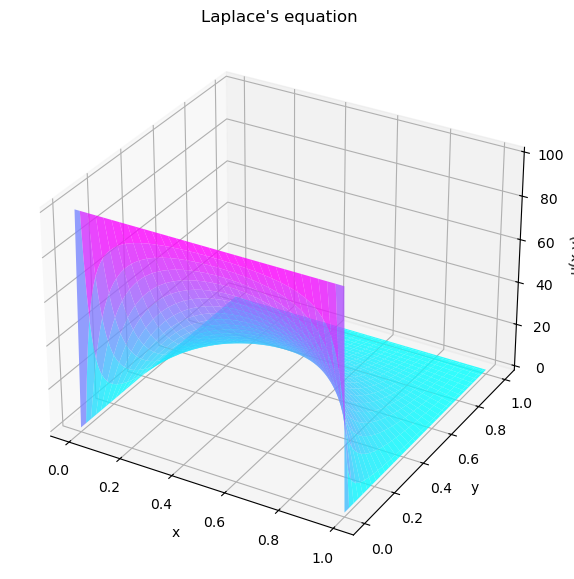

In [3]:
N = 100
tol = 1e-3
L = 1
h = L/N
V0 = 100
max_iter = 20000 #como jacobi converge lento tomamos un valor grandecito para que el programa no se detenga después de estas iteraciones.

#Malla
x = np.linspace(0,L,N+1)
y = np.linspace(0,L,N+1)

u = np.zeros((N+1,N+1))#matriz de zeros en donde voy a guardar la solución
u_new = np.zeros_like(u)#matriz de ceros en donde se guarda la nueva iteración 

#condiciones de frontera
u[:,0] = V0
u[0,:] = 0
u[N,:] = 0
u[:,N] = 0

u_new[:] = u[:]

error=1
iter = 0

while error>tol and iter < max_iter:
    for i in range(1,N):
        for j in range(1,N):
            u_new[i,j] = 0.25*(u[i+1,j]+u[i-1,j]+u[i,j+1]+u[i,j-1])
    u_new[:,0] = V0
    u_new[0,:] = 0
    u_new[N,:] = 0
    u_new[:,N] = 0

    error = np.max(np.abs(u_new - u))
    u[:,:] = u_new[:,:]
    iter = iter+1
u_jacobi = u.copy()

print("iteraciones", iter)
print("error final", error)

X,Y = np.meshgrid(x,y, indexing="ij")

fig = plt.figure(figsize=(8, 7))
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, u, cmap='cool', alpha=0.8)

ax.set_title("Laplace's equation")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('u(x,y)')

plt.show()


La estrategia usada fue dividir el cuadrado en una malla, fijamos los valores de frontera dados, damos una estimación inicial para los puntos (que es cero) y la idea es que en cada iteración, cada punto interior se reemplaza por el promedio de sus 4 vecinos.
Y la idea de la tolerancia es que este proceso se repita hasta que la resta entre una iteración y la siguiente sean menores que la tolerancia = $10^{-3}$ al procedimiento también le incluimos un maximo de iteraciones que puede hacer esto con el fin de que el while no se quede computando "para siempre" y tome este valor como 20000 porque jacobi converge lento entonces no quería quedarme sin iteraciones antes de que el programa terminará de correr. 

### Punto 3.

In [4]:
"""
Acá vamos a hacer el código para truncar la serie y la idea es mirar el error de max|u_m+1(x,y)-u_m(x,y)|
si esto baja de 10^-3 entonces con ese número de terminos alcanzamos la tolerancia
"""

#Define the n-esimo modo
#def un(x,y,n=1,L=1):
'function to compute the n-esimo term of the Fouriers serie'
  #return (4*V0/(n*np.pi))*np.sin(n*np.pi*x/L)*np.sinh(n*np.pi*(L-y)/L)/np.sinh(n*np.pi)

"""
usando la función "un" el error final entre las truncaciones me da "nan" esto puede deberse
a que el número de terminos impares que se necesita es grande y como este número es grande entonces
los sinh se vuelven enormes y computacionalmente puede parecer infinito entonces
cuando aparece infinito el código hace una operación indeterminada y entonces se presenta el nan

por esta razon voy a usar otra forma para escribir los sinh de la solución de Fourier
(con exponenciales)
"""

def un(x,y,n=1,L=1):
    a = n*np.pi/L
    razon = np.exp(-a*y)*(1 - np.exp(-2*a*(L-y))) / (1 - np.exp(-2*n*np.pi))
    return (4*V0/(n*np.pi)) * np.sin(n*np.pi*x/L) * razon

coordx = np.linspace(0,L,N+1) # 100 puntos
coordy = coordx
x , y = np.meshgrid(coordx, coordy, indexing= 'ij')

M = 1
error = 1.0
iter_fourier = 0
max_iter_fourier = 500
u_old = un(x,y,n=1,L=L)

while error > tol and iter_fourier < max_iter_fourier:
    M = M+1
    n = 2*M-1
    u_new = u_old + un(x,y,n=n,L=L)
    error = np.max(np.abs(u_new - u_old))
    u_old = u_new.copy()
    iter_fourier = iter_fourier + 1

uF = u_old.copy()

print("El número de términos impares que necesitaria son:", M)
print("El error final entre las truncaciones es:", error)

print("Valor de la solución de Fourier en el centro:", uF[N//2, N//2])

El número de términos impares que necesitaria son: 501
El error final entre las truncaciones es: 0.12719675771579375
Valor de la solución de Fourier en el centro: 25.000000000000004


In [5]:
error_comparacion = np.max(np.abs(uF-u_jacobi))
print("Error máximo entre Fourier y diferencias finitas es: ", error_comparacion)

"""
las esquinas y las fronteras pueden dar diferencias extrañas debido a la discontinuidad 
en estos puntos así que la compararemos solo en el interior también.
"""

error_comparacion_int= np.max(np.abs(uF[1:-1,1:-1]- u_jacobi[1:-1,1:-1]))
print("Error máximo eentre Fourier y diferencias finitas en el interior es: ", error_comparacion_int)

Error máximo entre Fourier y diferencias finitas es:  2.022921305899523
Error máximo eentre Fourier y diferencias finitas en el interior es:  2.022921305899523


## Ejercicio 2: diferencias finitas para fronteras abiertas.
Resuelva analitíca y numéricamente la ecuación de Laplace para $u(x,y)$ en el dominio $0\leq x \leq L$ y $0 \leq y < \infty$ con condiciones de frontera de Dirichlet's:

$u(x,0) = V(x) = u_0 sin(2\pi x/L)\exp^{-2\pi y/L}$

$u(0,y)=0$

$u(L,y)=0$

$u(x, \infty)=0$

Para resolver la ecuación de Laplace numéricamente, establecemos: $L=N\Delta = 100$ y $\Delta = 1$ y $\mu _0 = 100$

## Solución anatílica.

ecuación de laplace: $\frac{\partial ^2u}{\partial x^2} + \frac{\partial ^2u}{\partial y^2} = 0$ 

Para resolver la ecuación de Laplace usamos el método de separación de variables.

$u(x,y) = X(x)Y(y)$ Buscamos una solución de este tipo

sustiyendo en la ecuación de Laplace: $X''(x)Y(y)+X(x)Y''(y) = 0$

$\frac{X''(x)}{X(x)} = -\frac{Y''(y)}{Y(y)}$

Ahora ambos deben ser iguales a una constante sea esta constante $\alpha$

$\frac{X''(x)}{X(x)} = -\alpha$ y $\frac{Y''(y)}{Y(y)} = \alpha$

Por lo tanto, se obtienen estas dos ecuaciones:

$X'' + \alpha X = 0$

$Y'' - \alpha Y = 0$

Ahora resolvemos estas dos ecuaciones:

## Para X(x)
Para $x$ las condiciones de frontera son: 

$u(0,y) = 0$ y $u(L,y) = 0$

Como $u(x,y) = X(x)Y(y)$ entonces $X(0) = 0$ y X(L)=0

y la solución general para $X'' + \alpha X = 0$ es $X(x) = Acos(\sqrt{\alpha} x) + Bsin(\sqrt{\alpha} x)$

aplicamos $X(0) = 0$, entonces $X(0) = A = 0$. 

Entonces queda: $X(x) = Bsin(\sqrt{\alpha}x)$

Ahora con la siguiente condición: $X(L) = 0$

$Bsin(\sqrt{\alpha}L) = 0$

Entonces: $sin(\sqrt{alpha}L) = 0$ por lo tanto $\sqrt{alpha}L = n\pi$, $n = 1,2,3...$

por lo tanto: $\sqrt{\alpha} = \frac{n\pi}{L}$ y $\alpha _n = (\frac{n\pi}{L})$
^2$

finalmente los modos en $x$ son: $$X_n(x) = sin(\frac{n\pi x}{L})$$

## Para Y(y)

$Y''-\alpha _n Y = 0$

$Y'' - (\frac{n\pi}{L})^2 Y$

La solución general es: $Y_n (y) = C\exp{(n\pi y /L)} + D \exp{(-n\pi y /L)}$

Y la condición de frontera es: $u(x,\infty) = 0$

Para que la solución permanezca finita cuando $y \rightarrow \infty $ entonces no podemos aceptar el termino creciente por lo tanto $C=0$ y nos queda:

$$Y_n (y)= D\exp{(-n\pi y/L)}$$

como $u(x,y) = X(x)Y(y)$ entonces multiplicamos: 

$$u_n(x,y)= A_n sin(\frac{n\pi x}{L}) \exp{(-n\pi y/L)}$$

(Esto es para cada modo)

Ya la solución general es la suma de todos los modos:

$$u(x,y) = \sum_{n=1}^{\infty} A_n sin(\frac{n \pi x}{L})\exp{(-n\pi y/L)}$$

Ahora sabemos que $u(x,0) = u_0 sin(\frac{2 \pi x}{L})$ pues por las condiciones de frontera 

Entonces en la solución general: $u(x,0) = \sum_{n=1}^{\infty} A_n sin(\frac{n\pi x}{L})$ entonces igualamos.

$\sum_{n=1}^{\infty} A_n sin(\frac{n \pi x}{L}) = u_0 sin(\frac{2\pi x}{L})$ 

De aqui podemos observar que: $A_2 = u_0$ y todos los demas coeficientes son cero $A_n = 0 $ si $n\neq 2$

Entonces para estas condiciones de frontera finalmente la solución queda como: $$u(x,y) = u_0 sin(\frac{2\pi x}{L})\exp{(-2\pi y/L)}$$

Y para los valores de $u_0 = 100$ y $L = 100$ queda:

$$u(x,y) = 100 sin(\frac{\pi x}{50}) \exp{(-\pi y/50)}$$







In [6]:
#Solución numérica por diferencias finitas
L_2 = 100
delta = 1
N_2 = int(L_2/delta)
u0 = 100
Ny = 100 #esto es porque no podemos poner "y" igual a infinito entonces tomamos un número alto
tol_2 = 1e-3
max_iter_2 = 20000

x_2 = np.linspace(0,L_2,N_2 +1)
y_2 = np.linspace(0, Ny, Ny+1)

u_2 = np.zeros((N_2+1 , Ny+1))
u_nueva = np.zeros_like(u_2)

u_2[:,0] = u0 * np.sin(2*np.pi*x_2/L_2)
u_2[0,:] = 0
u_2[N_2,:] = 0
u_2[:,Ny] = 0

u_nueva[:] = u_2[:]

iteraciones = 0
error_2 = 1

while error_2 > tol_2 and iteraciones < max_iter_2:
    for i in range(1,N_2):
        for j in range(1, Ny):
            u_nueva[i,j] = 0.25*(u_2[i+1,j]+u_2[i-1,j]+u_2[i,j+1]+u_2[i,j-1])
    u_nueva[:,0] = u0* np.sin(2*np.pi*(x_2) /L_2)
    u_nueva[0,:] = 0
    u_nueva[N_2,:] = 0
    u_nueva[:,Ny] = 0

    error_2 = np.max(np.abs(u_nueva - u_2))
    u_2[:,:] = u_nueva[:,:]
    iteraciones = iteraciones + 1

sol_u_jacobi = u_2.copy()

print("Iteraciones:", iteraciones)
print("error final", error_2)




Iteraciones: 2359
error final 0.0009992270369423295


In [9]:
#vamos a comparar la solución analítica con la numérica

X, Y = np.meshgrid(x_2,y_2,indexing='ij')
u_analitica = u0*np.sin(2*np.pi*X/L_2) * np.exp(-2*np.pi*Y/L_2)

error_de_comp = np.max(np.abs(sol_u_jacobi - u_analitica))
print("Error máximo entre solución numérica y analítica:", error_de_comp)

Error máximo entre solución numérica y analítica: 0.7410170902669897


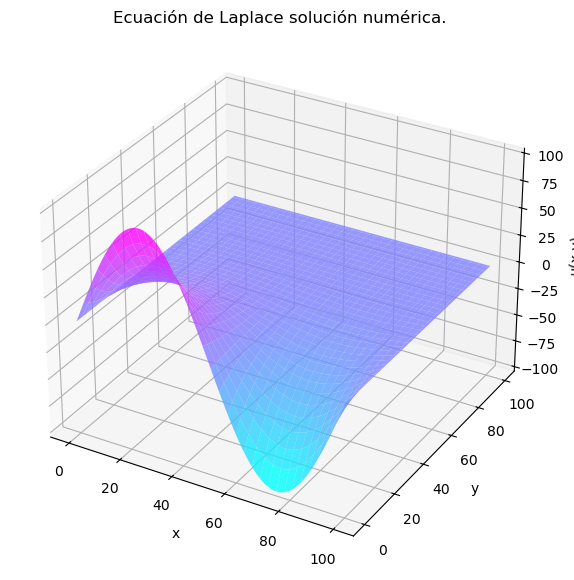

In [10]:
#grafica
fig = plt.figure(figsize=(8,7))
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, sol_u_jacobi, cmap='cool', alpha=0.8)
ax.set_title("Ecuación de Laplace solución numérica.")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("u(x,y)")
plt.show()